Name: vartika, roll no.: 2300291520202

Load a CSV dataset

Cluster using EM algorithm (Gaussian Mixture Model)

Cluster using K-Means

Cluster using K-Medoids

Compare results

In [6]:
# 1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")


In [7]:
# Load CSV dataset
data = pd.read_csv(r"C:\Users\asus new\Downloads\customers-100.csv")

# Select numeric columns only for clustering
numeric_cols = data.select_dtypes(include=np.number).columns
X = data[numeric_cols]

# Fill missing values
X = X.fillna(X.mean())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Columns used: {numeric_cols.tolist()}")
print(f"Scaled data shape: {X_scaled.shape}")


Columns used: ['Index']
Scaled data shape: (100, 1)


In [8]:
n_clusters = 3  # You can change this

gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
print(f"EM (GMM) silhouette score: {gmm_silhouette:.4f}")


EM (GMM) silhouette score: 0.5774


C:\Users\asus new\.android\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means silhouette score: {kmeans_silhouette:.4f}")


K-Means silhouette score: 0.5773


C:\Users\asus new\.android\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
results = pd.DataFrame({
    "Algorithm": ["EM (GMM)", "K-Means"],
    "Silhouette Score": [gmm_silhouette, kmeans_silhouette]
})

print(results)


  Algorithm  Silhouette Score
0  EM (GMM)          0.577362
1   K-Means          0.577349


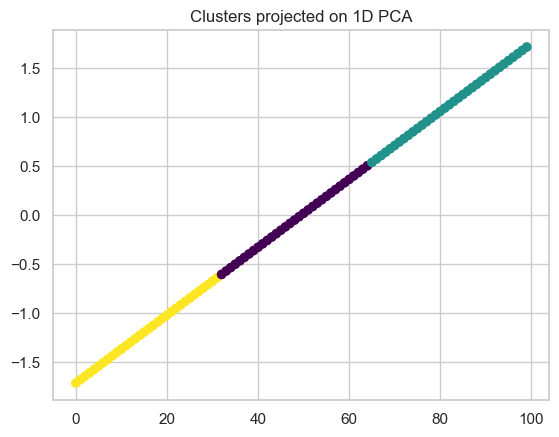

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)  # Only 1 numeric column exists
X_pca = pca.fit_transform(X_scaled)

# Now plot
plt.scatter(range(len(X_pca)), X_pca, c=kmeans_labels, cmap='viridis')
plt.title("Clusters projected on 1D PCA")
plt.show()

